In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("PUDF_base1_1q2019_cleaned.csv")
df.head()

,RECORD_ID,DISCHARGE,THCIC_ID,TYPE_OF_ADMISSION,SOURCE_OF_ADMISSION,PAT_STATE,PAT_ZIP,PAT_COUNTRY,PAT_COUNTY,PUBLIC_HEALTH_REGION,...,CODE_16,CODE_17,CODE_18,CODE_19,CODE_20,CODE_21,CODE_22,PAT_RURAL,PROVIDER_ZIP,PROVIDER_RURAL
0,120190000375,2019Q1,703003,3.0,2,TX,78418,US,355.0,11.0,...,0,0,0,0,0,0,0,0,78413,0
1,120190000376,2019Q1,703003,1.0,1,TX,78335,US,409.0,11.0,...,0,0,1,0,0,0,0,0,78413,0
2,120190000377,2019Q1,703003,3.0,2,TX,78336,US,409.0,11.0,...,0,0,0,0,0,0,0,0,78413,0
3,120190000378,2019Q1,703003,3.0,2,TX,78411,US,355.0,11.0,...,0,0,0,0,0,0,0,0,78413,0
4,120190000379,2019Q1,703003,3.0,2,TX,78414,US,355.0,11.0,...,0,0,0,0,0,0,0,0,78413,0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 655221 entries, 0 to 655220
Data columns (total 44 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   RECORD_ID             655221 non-null  int64  
 1   DISCHARGE             655221 non-null  str    
 2   THCIC_ID              655221 non-null  int64  
 3   TYPE_OF_ADMISSION     655221 non-null  float64
 4   SOURCE_OF_ADMISSION   655221 non-null  str    
 5   PAT_STATE             655221 non-null  str    
 6   PAT_ZIP               655221 non-null  int64  
 7   PAT_COUNTRY           655221 non-null  str    
 8   PAT_COUNTY            655221 non-null  float64
 9   PUBLIC_HEALTH_REGION  655221 non-null  float64
 10  PAT_STATUS            655221 non-null  int64  
 11  SEX_CODE              655221 non-null  str    
 12  RACE                  655221 non-null  int64  
 13  ETHNICITY             655221 non-null  int64  
 14  ADMIT_WEEKDAY         655221 non-null  float64
 15  LENGTH_OF_S

In [16]:
df['NUM_CODES'] = df.iloc[:, 19:41].sum(axis = 1)
df['NUM_CODES'].describe()

count    655221.000000
mean          4.476615
std           2.691292
min           0.000000
25%           2.000000
50%           4.000000
75%           7.000000
max          15.000000
Name: NUM_CODES, dtype: float64

In [32]:
df1 = df.loc[df.LENGTH_OF_STAY < 50]

<Axes: xlabel='CODE_5', ylabel='LENGTH_OF_STAY'>

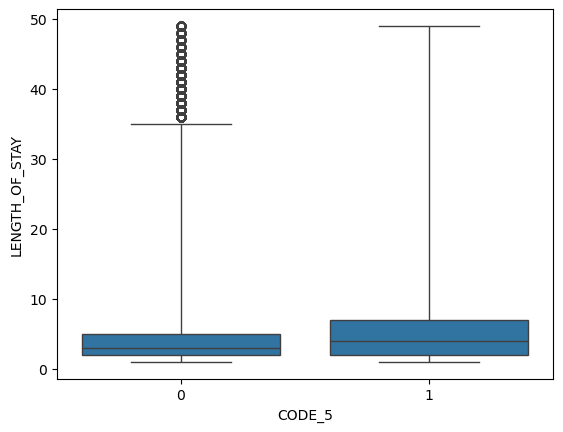

In [43]:
sns.boxplot(data = df1, x = 'CODE_5', y = 'LENGTH_OF_STAY', whis = 10.0)

In [62]:
# Descriptive Statistics of Codes with no clipping
code_df = pd.DataFrame()
code_df['count'] = df.iloc[:, 19:40].apply(lambda col: df.loc[col == 1, 'LENGTH_OF_STAY'].count())
code_df['mean'] = df.iloc[:, 19:40].apply(lambda col: df.loc[col == 1, 'LENGTH_OF_STAY'].mean())
code_df['min'] = df.iloc[:, 19:40].apply(lambda col: df.loc[col == 1, 'LENGTH_OF_STAY'].min())
code_df['Q1'] = df.iloc[:, 19:40].apply(lambda col: df.loc[col == 1, 'LENGTH_OF_STAY'].quantile(.25))
code_df['median'] = df.iloc[:, 19:40].apply(lambda col: df.loc[col == 1, 'LENGTH_OF_STAY'].median())
code_df['Q3'] = df.iloc[:, 19:40].apply(lambda col: df.loc[col == 1, 'LENGTH_OF_STAY'].quantile(.75))
code_df['max'] = df.iloc[:, 19:40].apply(lambda col: df.loc[col == 1, 'LENGTH_OF_STAY'].max())
code_df['std'] = df.iloc[:, 19:40].apply(lambda col: df.loc[col == 1, 'LENGTH_OF_STAY'].std())
code_df['effect'] = df.iloc[:, 19:40].apply(lambda col: df.loc[col == 1, 'LENGTH_OF_STAY'].mean() - df['LENGTH_OF_STAY'].mean())

code_df.sort_values(by = 'effect', ascending = False)

,count,mean,min,Q1,median,Q3,max,std,effect
CODE_20,8,44.250000,1.0,2.75,7.5,60.0,209.0,71.581622,39.189141
CODE_17,1622,10.208385,1.0,2.00,4.0,8.0,392.0,24.318313,5.147526
CODE_12,54326,8.016401,1.0,3.00,5.0,9.0,723.0,10.272648,2.955542
CODE_7,21572,7.324680,1.0,2.00,4.0,8.0,314.0,12.321294,2.263821
CODE_1,107698,7.223700,1.0,3.00,5.0,8.0,339.0,8.797932,2.162841
CODE_19,88421,6.621787,1.0,2.00,4.0,8.0,905.0,9.055311,1.560928
CODE_6,169112,6.577209,1.0,2.00,4.0,8.0,1052.0,9.034142,1.516350
CODE_3,165011,6.564478,1.0,2.00,4.0,8.0,905.0,8.040256,1.503619
CODE_16,42380,6.291977,1.0,2.00,2.0,4.0,601.0,15.600440,1.231118
CODE_2,62388,6.267616,1.0,2.00,4.0,7.0,379.0,7.661661,1.206757


In [67]:
# Descriptive Statistics of Codes with upper value of LOS clipped at 30
df1 = df.copy()
df1['LENGTH_OF_STAY'] = df1['LENGTH_OF_STAY'].clip(upper = 30)

code_df1 = pd.DataFrame()
code_df1['count'] = df1.iloc[:, 19:40].apply(lambda col: df1.loc[col == 1, 'LENGTH_OF_STAY'].count())
code_df1['mean'] = df1.iloc[:, 19:40].apply(lambda col: df1.loc[col == 1, 'LENGTH_OF_STAY'].mean())
code_df1['min'] = df1.iloc[:, 19:40].apply(lambda col: df1.loc[col == 1, 'LENGTH_OF_STAY'].min())
code_df1['Q1'] = df1.iloc[:, 19:40].apply(lambda col: df1.loc[col == 1, 'LENGTH_OF_STAY'].quantile(.25))
code_df1['median'] = df1.iloc[:, 19:40].apply(lambda col: df1.loc[col == 1, 'LENGTH_OF_STAY'].median())
code_df1['Q3'] = df1.iloc[:, 19:40].apply(lambda col: df1.loc[col == 1, 'LENGTH_OF_STAY'].quantile(.75))
code_df1['max'] = df1.iloc[:, 19:40].apply(lambda col: df1.loc[col == 1, 'LENGTH_OF_STAY'].max())
code_df1['std'] = df1.iloc[:, 19:40].apply(lambda col: df1.loc[col == 1, 'LENGTH_OF_STAY'].std())
code_df1['effect'] = df1.iloc[:, 19:40].apply(lambda col: df1.loc[col == 1, 'LENGTH_OF_STAY'].mean() - df1['LENGTH_OF_STAY'].mean())

code_df1.sort_values(by = 'mean', ascending = False)

,count,mean,min,Q1,median,Q3,max,std,effect
CODE_20,8,13.875000,1.0,2.75,7.5,30.0,30.0,13.579791,9.148645
CODE_12,54326,7.502614,1.0,3.00,5.0,9.0,30.0,6.876448,2.776259
CODE_17,1622,7.085697,1.0,2.00,4.0,8.0,30.0,8.311676,2.359342
CODE_1,107698,6.846766,1.0,3.00,5.0,8.0,30.0,6.269263,2.120411
CODE_7,21572,6.409234,1.0,2.00,4.0,8.0,30.0,6.394823,1.682879
CODE_3,165011,6.303889,1.0,2.00,4.0,8.0,30.0,5.937474,1.577534
CODE_19,88421,6.302881,1.0,2.00,4.0,8.0,30.0,5.947757,1.576526
CODE_6,169112,6.266445,1.0,2.00,4.0,8.0,30.0,6.021516,1.540090
CODE_2,62388,6.020917,1.0,2.00,4.0,7.0,30.0,5.829648,1.294563
CODE_14,214096,5.964133,1.0,2.00,4.0,7.0,30.0,5.715803,1.237778


In [90]:
# Dataframe with LOS clipped at 100
df2 = df.copy()
df2['LENGTH_OF_STAY'] = df2['LENGTH_OF_STAY'].clip(upper = 100)
df2.head()

,RECORD_ID,DISCHARGE,THCIC_ID,TYPE_OF_ADMISSION,SOURCE_OF_ADMISSION,PAT_STATE,PAT_ZIP,PAT_COUNTRY,PAT_COUNTY,PUBLIC_HEALTH_REGION,...,CODE_17,CODE_18,CODE_19,CODE_20,CODE_21,CODE_22,PAT_RURAL,PROVIDER_ZIP,PROVIDER_RURAL,NUM_CODES
0,120190000375,2019Q1,703003,3.0,2,TX,78418,US,355.0,11.0,...,0,0,0,0,0,0,0,78413,0,4
1,120190000376,2019Q1,703003,1.0,1,TX,78335,US,409.0,11.0,...,0,1,0,0,0,0,0,78413,0,10
2,120190000377,2019Q1,703003,3.0,2,TX,78336,US,409.0,11.0,...,0,0,0,0,0,0,0,78413,0,2
3,120190000378,2019Q1,703003,3.0,2,TX,78411,US,355.0,11.0,...,0,0,0,0,0,0,0,78413,0,4
4,120190000379,2019Q1,703003,3.0,2,TX,78414,US,355.0,11.0,...,0,0,0,0,0,0,0,78413,0,2


<Axes: >

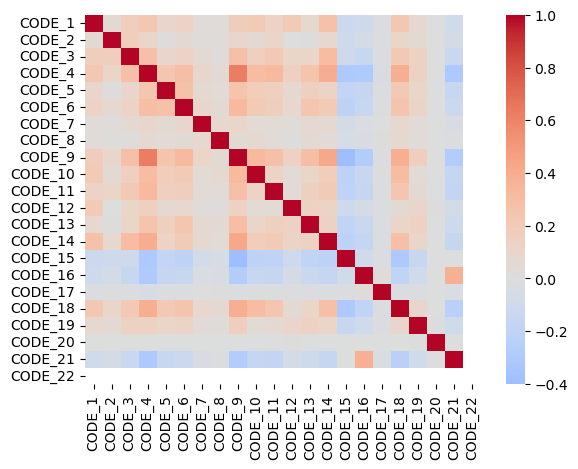

In [68]:
# Heatmap to see correlation of when codes appear

corr = df.iloc[:, 19:41].corr()

sns.heatmap(corr,
            cmap='coolwarm',
            center=0)

<Axes: >

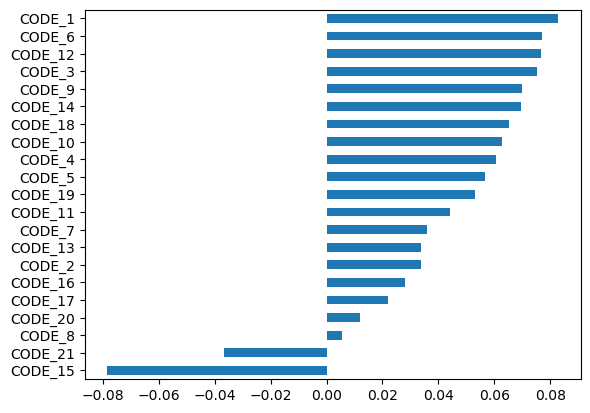

In [70]:
# Chart showing correlation with LOS for each code
corr_los = df.iloc[:, 19:40].corrwith(df['LENGTH_OF_STAY'])
corr_los.sort_values()
corr_los.sort_values().plot.barh()

<Axes: >

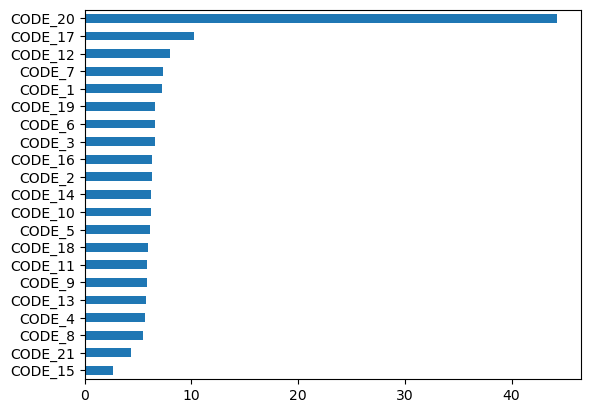

In [71]:
# Chart showing the mean LOS of each code sorted
means = df.iloc[:, 19:40].apply(
    lambda x: df.loc[x == 1, 'LENGTH_OF_STAY'].mean()
)

means.sort_values().plot.barh()

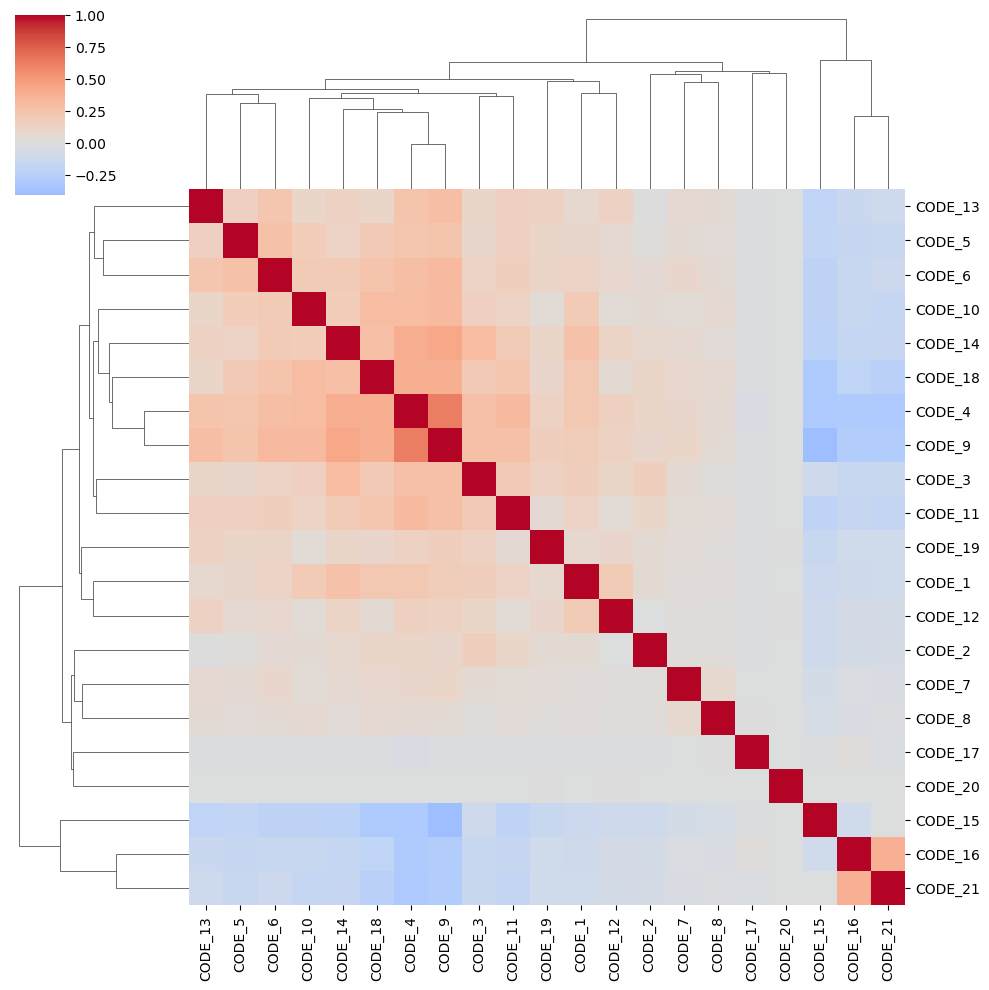

In [72]:
# Heatmap sorted into clusters of codes with most incidences.
sns.clustermap(df.iloc[:, 19:40].corr(),
               cmap='coolwarm',
               center=0)

<Axes: xlabel='NUM_CODES', ylabel='LENGTH_OF_STAY'>

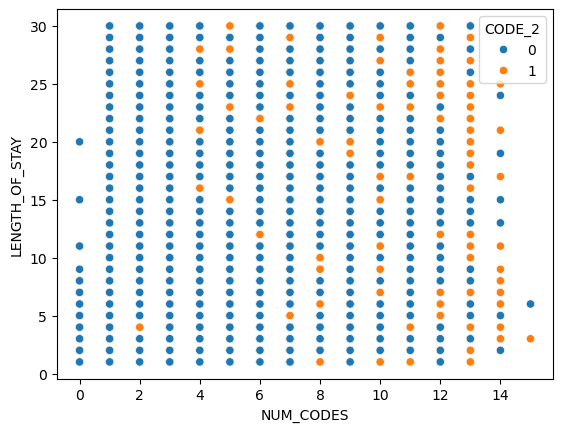

In [82]:
sns.scatterplot(df1, x = 'NUM_CODES', y='LENGTH_OF_STAY', hue = 'CODE_2')

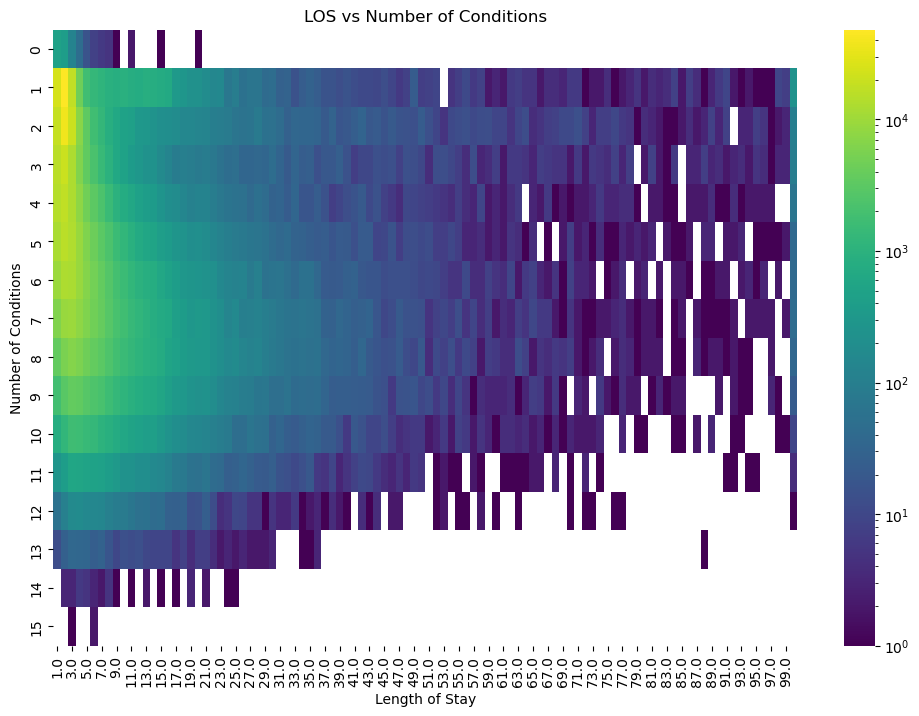

In [91]:
# Heatmap showing a general trend of LOS going up with number of conditions going up
from matplotlib.colors import LogNorm
heat = pd.crosstab(df2['NUM_CODES'], df2['LENGTH_OF_STAY'])

plt.figure(figsize=(12,8))
sns.heatmap(heat, cmap='viridis', norm = LogNorm())
plt.xlabel('Length of Stay')
plt.ylabel('Number of Conditions')
plt.title('LOS vs Number of Conditions')
plt.show()

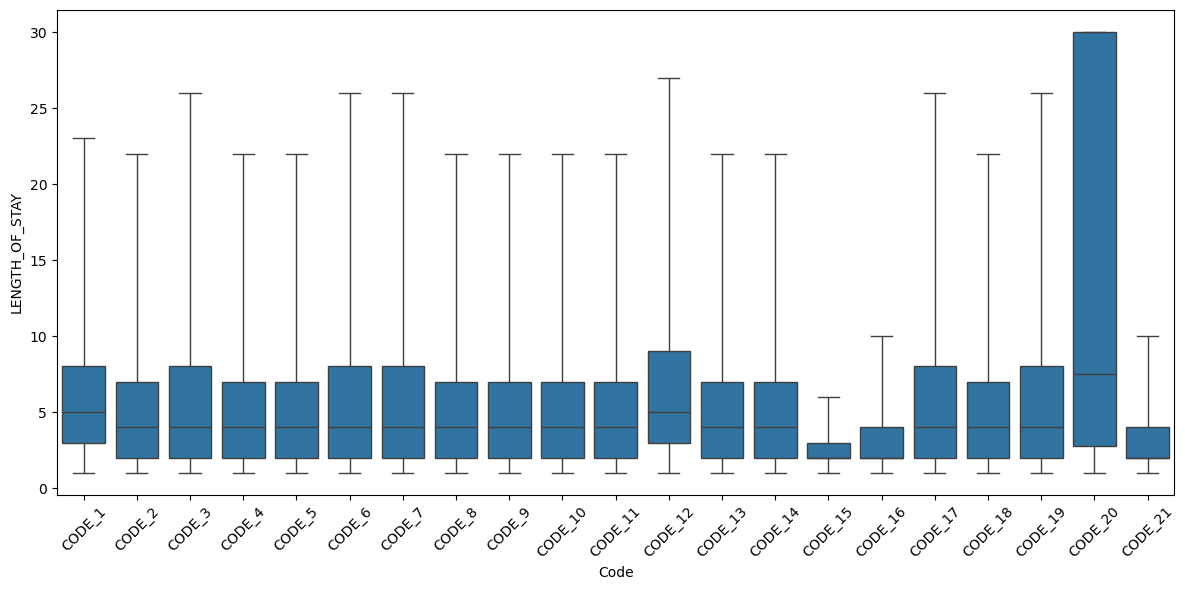

In [97]:
#Boxplots of each code with values clipped at 30
# Select the code columns
code_cols = [f'CODE_{i}' for i in range(1, 23)]

# Convert from wide to long
long_df = (
    df1.melt(
        id_vars='LENGTH_OF_STAY',
        value_vars=code_cols,
        var_name='Code',
        value_name='Present'
    )
)

# Keep only rows where the code is present
long_df = long_df[long_df['Present'] == 1]

plt.figure(figsize=(12,6))

sns.boxplot(
    data=long_df,
    x='Code',
    y='LENGTH_OF_STAY',
    whis=3.0,
    showfliers=False
)

plt.xticks(rotation=45)
plt.tight_layout()